In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded=files.upload()

Saving CC GENERAL.csv to CC GENERAL.csv


In [8]:
df=pd.read_csv('/content/CC GENERAL.csv')

In [9]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [11]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [12]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [13]:
df.shape

(8950, 18)

In [14]:
df.drop(["CUST_ID"], axis=1, inplace=True)

In [15]:
# Feature Engineering

df["TOTAL_SPENDING"] = df["PURCHASES"] + df["ONEOFF_PURCHASES"] + df["INSTALLMENTS_PURCHASES"]

df["CREDIT_UTILIZATION"] = df["BALANCE"] / (df["CREDIT_LIMIT"] + 1)

df["CASH_ADV_RATIO"] = df["CASH_ADVANCE"] / (df["BALANCE"] + 1)

df["PAYMENT_RATIO"] = df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + 1)

df["PURCHASE_SCORE"] = (
    df["PURCHASES_FREQUENCY"] +
    df["ONEOFF_PURCHASES_FREQUENCY"] +
    df["PURCHASES_INSTALLMENTS_FREQUENCY"]
)

df["AVG_PURCHASE"] = df["PURCHASES"] / (df["PURCHASES_TRX"] + 1)

df["AVG_CASH_ADVANCE"] = df["CASH_ADVANCE"] / (df["CASH_ADVANCE_TRX"] + 1)

In [16]:
df.shape

(8950, 24)

In [21]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import pandas as pd


for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(df)

hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

df["Cluster"] = clusters

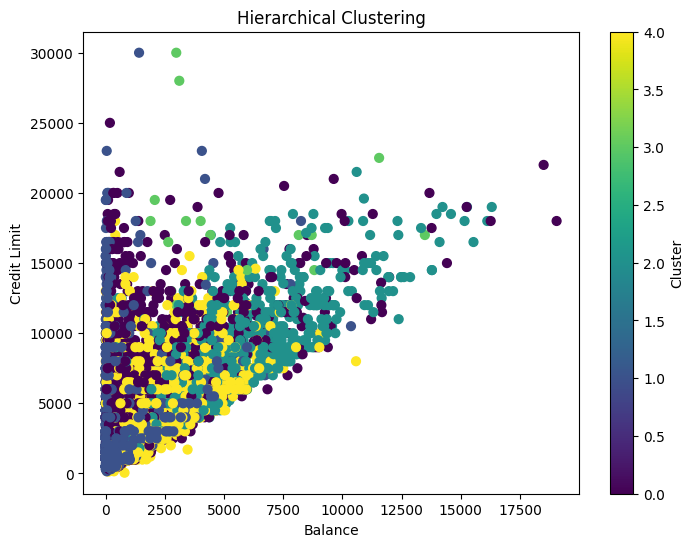

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["BALANCE"],
    df["CREDIT_LIMIT"],
    c=df["Cluster"],
    cmap="viridis",
    s=40
)

plt.xlabel("Balance")
plt.ylabel("Credit Limit")
plt.title("Hierarchical Clustering")
plt.colorbar(label="Cluster")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42
)

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",
    linkage="ward"
)

train_clusters = hc.fit_predict(X_train)
test_clusters = hc.fit_predict(X_test)

In [28]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",
    linkage="ward"
)

clusters = hc.fit_predict(X_scaled)

df["Cluster"] = clusters

In [29]:
from sklearn.metrics import silhouette_score

train_score = silhouette_score(X_train, train_clusters)

print("Training Silhouette Score:", train_score)

Training Silhouette Score: 0.10532362529731634


In [30]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",
    linkage="ward"
)

clusters = hc.fit_predict(X_scaled)

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.15461821880210336


In [31]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

best_score = -1
best_k = 2

for k in range(2, 11):
    hc = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )

    labels = hc.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    print(f"k={k}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print("\nBest K:", best_k)
print("Best Score:", best_score)


k=2: 0.1795
k=3: 0.1831
k=4: 0.1817
k=5: 0.1546
k=6: 0.1410
k=7: 0.1449
k=8: 0.1652
k=9: 0.1676
k=10: 0.1703

Best K: 3
Best Score: 0.18307597717452465
